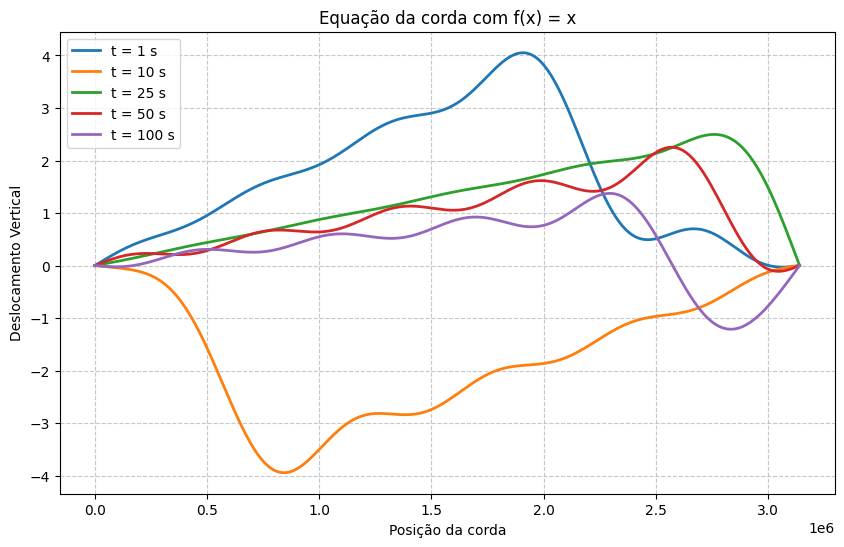

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math

# ==========================================
# 1. Parâmetros Físicos 
# ==========================================
L = np.pi          # Comprimento da corda
a = 1              # Velocidade de propagação da onda (m/s)
N_termos = 10      # Quantidade de termos da série de Fourier

# ==========================================
# 2. Condição Inicial g(x)
# ==========================================
def g(x):
    # Condição inicial: g(x) = x
    return x

def f(x):
    # Condição inicial: g(x) = x
    return x

# ==========================================
# 3. Pré-cálculo dos Coeficientes
# ==========================================
def calcula_cn_a(n, L):
    integrando = lambda x: f(x) * np.sin((n * np.pi * x) / L)
    integral, _ = quad(integrando, 0, L)
    return (1 / L) * integral

def calcula_cn_b(n, L):
    integrando = lambda x: g(x) * np.sin((n * np.pi * x) / L)
    integral, _ = quad(integrando, 0, L)
    return (1 / (a * np.pi * n)) * integral
# Pré-calculamos a integral apenas uma vez para economizar processamento
cn_values_a = [calcula_cn_a(n, L) for n in range(1, N_termos + 1)]

cn_values_b = [calcula_cn_b(n, L) for n in range(1, N_termos + 1)]
# ==========================================
# 4. Solução Matemática u(x,t)
# ==========================================
def eq_corda_geral(x, t, L, a, N, coeficientes_a, coeficientes_b):
    soma_a = np.zeros_like(x)
    soma_b = np.zeros_like(x)
    soma_geral = np.zeros_like(x)
    for n in range(1, N + 1):
        cn = coeficientes_a[n-1]
        termo = cn * np.sin((n * np.pi * x) / L) * np.cos((n * np.pi * a * t) / L)
        soma_a += termo
    for n in range(1, N + 1):
        cn = coeficientes_b[n-1]
        termo = cn * np.sin(n * np.pi * x / L) * np.sin(n * np.pi * a * t / L)
        soma_b += termo
    soma_geral = 2 * (soma_a + soma_b)
    return soma_geral

# ==========================================
# 5. Simulação e Gráficos
# ==========================================
# 200 pontos espaciais para criar uma curva suave
x = np.linspace(0, L, 200)

# Tempos que queremos observar (em nanossegundos)
tempos = [1, 10, 25, 50, 100] 

plt.figure(figsize=(10, 6))

for t in tempos:
    equacao_corda = eq_corda_geral(x, t, L, a, N_termos, cn_values_a, cn_values_b)
    
    plt.plot(x * 1e6, equacao_corda, label=f't = {t} s', linewidth=2)

plt.title('Equação da corda com f(x) = x')
plt.xlabel(r'Posição da corda')
plt.ylabel('Deslocamento Vertical')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()